# References

link github: https://github.com/keras-team/keras-io/blob/master/examples/vision/ipynb/image_classification_with_vision_transformer.ipynb

articel : https://arxiv.org/pdf/2010.11929

# Introduction
This example implements the Vision Transformer (ViT) model by Alexey Dosovitskiy et al. for image classification, and demonstrates it on the CIFAR-100 dataset. The ViT model applies the Transformer architecture with self-attention to sequences of image patches, without using convolution layer

In [1]:
import matplotlib.pyplot as plt
import keras
from keras import layers
from keras import ops
from keras.utils import image_dataset_from_directory
import numpy as np
import tensorflow as tf

# Prepare the data

In [2]:
# 1. Prepare data
# ----------------------------------------------------------------------
# Load the datasets
data_dir = r"D:\faiza\data\spectogram4class"  # or wherever the data is
image_size = 128  # Consistent image size, from your provided image
batch_size = 32

train_ds = image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="categorical",
    image_size=(image_size, image_size),
    batch_size=batch_size,
    validation_split=0.2,
    subset="training",
    seed=42,
)
val_ds = image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="categorical",
    image_size=(image_size, image_size),
    batch_size=batch_size,
    validation_split=0.2,
    subset="validation",
    seed=42,
)
temp_ds = image_dataset_from_directory(  # added for visualization
    data_dir,
    labels="inferred",
    label_mode="categorical",
    image_size=(image_size, image_size),
    batch_size=1,
    shuffle=True,
)

Found 1628 files belonging to 4 classes.
Using 1303 files for training.
Found 1628 files belonging to 4 classes.
Using 325 files for validation.
Found 1628 files belonging to 4 classes.


# Configure the hyperparameters

In [3]:
# 2. Configure the hyperparameters
# ----------------------------------------------------------------------
patch_size = 16  # From your provided image
projection_dim = 64
num_heads = 4
transformer_units = [projection_dim * 2, projection_dim]
transformer_layers = 8
mlp_head_units = [2048, 1024]
num_classes = 4
num_epochs = 50 # 50
learning_rate = 0.001
weight_decay = 0.0001
input_shape = (image_size, image_size, 3)

# Use data augmentation

In [4]:
# 3. Use data augmentation
# ----------------------------------------------------------------------
data_augmentation = keras.Sequential(
    [
        layers.Normalization(),
        layers.Resizing(image_size, image_size),
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(factor=0.02),
        layers.RandomZoom(height_factor=0.2, width_factor=0.2),
    ],
    name="data_augmentation",
)

# Compute the mean and the variance of the training data for normalization.
#  Use .map to extract the images from the dataset
data_augmentation.layers[0].adapt(train_ds.map(lambda x, y: x))

# Implement multilayer perceptron (MLP)

In [5]:
# 4. Implement MLP
# ----------------------------------------------------------------------
def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=keras.activations.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x


# Implement patch creation as a layer

In [6]:
#5. Implement patch creation as a layer
# ----------------------------------------------------------------------
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        input_shape = ops.shape(images)
        batch_size = input_shape[0]
        height = input_shape[1]
        width = input_shape[2]
        channels = input_shape[3]
        num_patches_h = height // self.patch_size
        num_patches_w = width // self.patch_size
        patches = keras.ops.image.extract_patches(
            images,
            size=(self.patch_size, self.patch_size),
            strides=(self.patch_size, self.patch_size),
            padding="VALID",
        )
        patches = ops.reshape(
            patches,
            (
                batch_size,
                num_patches_h * num_patches_w,
                self.patch_size * self.patch_size * channels,
            ),
        )
        return patches

    def get_config(self):
        config = super().get_config()
        config.update({"patch_size": self.patch_size})
        return config


Lest display patches for a sample image

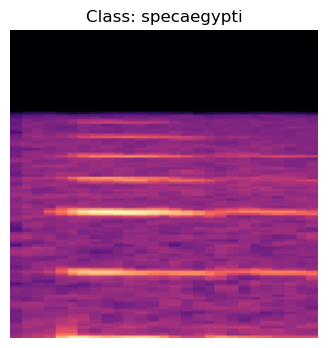

Image size: 128 X 128
Patch size: 16 X 16
Patches per image: 64
Elements per patch: 768


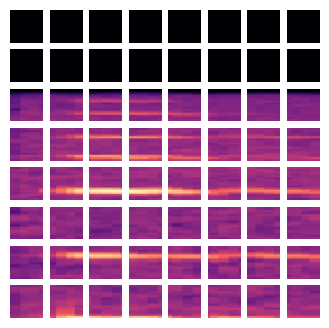

In [7]:
# 6. Get this output: Image size, Patch size, Patches per image, Elements per patch
# ----------------------------------------------------------------------
# Take one image
for image_batch, label_batch in temp_ds.take(1):
    image = image_batch[0]

    # Display the original image
    plt.figure(figsize=(4, 4))
    plt.imshow(ops.convert_to_numpy(image).astype("uint8"))
    plt.title(f"Class: {temp_ds.class_names[ops.convert_to_numpy(label_batch).argmax()]}")
    plt.axis("off")
    plt.show()

    resized_image = ops.image.resize(
        ops.expand_dims(image, axis=0), size=(image_size, image_size)
    )
    patches = Patches(patch_size)(resized_image)

    print(f"Image size: {image_size} X {image_size}")
    print(f"Patch size: {patch_size} X {patch_size}")
    print(f"Patches per image: {patches.shape[1]}")
    print(f"Elements per patch: {patches.shape[-1]}")

    n = int(np.sqrt(patches.shape[1]))
    plt.figure(figsize=(4, 4))
    for i, patch in enumerate(patches[0]):
        ax = plt.subplot(n, n, i + 1)
        patch_img = ops.reshape(patch, (patch_size, patch_size, ops.shape(image)[-1]))
        plt.imshow(ops.convert_to_numpy(patch_img).astype("uint8"))
        plt.axis("off")
    plt.show()


# Implement the patch encoding layer

In [8]:
# 7. Implement the patch encoding layer
# ----------------------------------------------------------------------
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = ops.expand_dims(
            ops.arange(start=0, stop=self.num_patches, step=1), axis=0
        )
        projected_patches = self.projection(patch)
        encoded = projected_patches + self.position_embedding(positions)
        return encoded

    def get_config(self):
        config = super().get_config()
        config.update({"num_patches": self.num_patches})
        return config


# Build the ViT model
The ViT model consists of multiple Transformer blocks, which use the layers.MultiHeadAttention layer as a self-attention mechanism applied to the sequence of patches. The Transformer blocks produce a [batch_size, num_patches, projection_dim] tensor, which is processed via an classifier head with softmax to produce the final class probabilities output.

Unlike the technique described in the paper, which prepends a learnable embedding to the sequence of encoded patches to serve as the image representation, all the outputs of the final Transformer block are reshaped with layers.Flatten() and used as the image representation input to the classifier head. Note that the layers.GlobalAveragePooling1D layer could also be used instead to aggregate the outputs of the Transformer block, especially when the number of patches and the projection dimensions are large.

In [9]:
# 8. Build the ViT model
# ----------------------------------------------------------------------
def create_vit_classifier():
    inputs = layers.Input(shape=input_shape)
    augmented_inputs = data_augmentation(inputs)  # Apply data augmentation
    patches = Patches(patch_size)(augmented_inputs)
    num_patches = (image_size // patch_size) ** 2
    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)

    for _ in range(transformer_layers):
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim, dropout=0.1
        )(x1, x1)
        x2 = layers.Add()([attention_output, encoded_patches])
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        x3 = mlp(x3, hidden_units=transformer_units, dropout_rate=0.1)
        encoded_patches = layers.Add()([x3, x2])

    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.Flatten()(representation)
    representation = layers.Dropout(0.5)(representation)
    features = mlp(representation, hidden_units=mlp_head_units, dropout_rate=0.5)
    logits = layers.Dense(num_classes, activation="softmax")(features)
    model = keras.Model(inputs=inputs, outputs=logits)
    return model

# Compile, train, and evaluate the mode


Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 43s 222ms/step - accuracy: 0.3895 - loss: 3.5349 - top-5-accuracy: 1.0000 - val_accuracy: 0.4554 - val_loss: 1.2513 - val_top-5-accuracy: 1.0000
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 175ms/step - accuracy: 0.5281 - loss: 1.3308 - top-5-accuracy: 1.0000 - val_accuracy: 0.6492 - val_loss: 0.7606 - val_top-5-accuracy: 1.0000
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 171ms/step - accuracy: 0.5827 - loss: 0.9350 - top-5-accuracy: 1.0000 - val_accuracy: 0.7046 - val_loss: 0.6816 - val_top-5-accuracy: 1.0000
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 6s 156ms/step - accuracy: 0.6052 - loss: 0.8564 - top-5-accuracy: 1.0000 - val_accuracy: 0.6708 - val_loss: 0.6628 - val_top-5-accuracy: 1.0000
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 174ms/step - accuracy: 0.6485 - loss: 0.7975 - top-5-accuracy: 1.0000 - val_accuracy: 0.7477 - val_loss: 0.6266 - val_top-5-accuracy: 1.0000
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 160ms/step - accuracy: 0.6839 - loss: 0.7175 - 

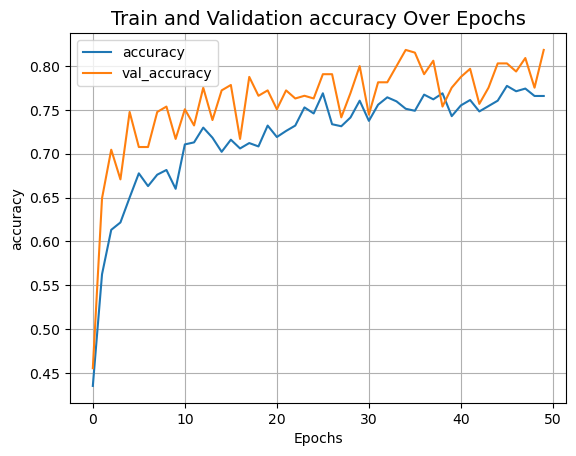

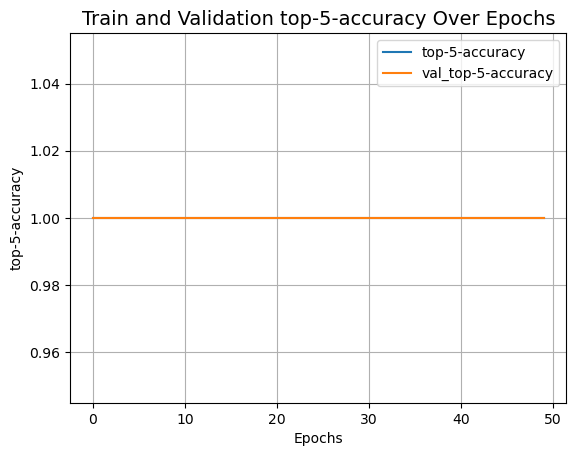

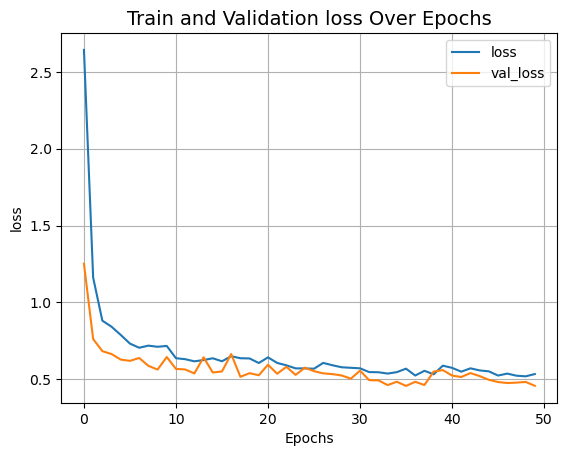

In [10]:
# 9. Compile, train, and evaluate the model
# ----------------------------------------------------------------------
def run_experiment(model):
    optimizer = keras.optimizers.AdamW(
        learning_rate=learning_rate, weight_decay=weight_decay
    )
    model.compile(
        optimizer=optimizer,
        loss=keras.losses.CategoricalCrossentropy(from_logits=False),
        metrics=[
            keras.metrics.CategoricalAccuracy(name="accuracy"),
            keras.metrics.TopKCategoricalAccuracy(5, name="top-5-accuracy"),
        ],
    )

    checkpoint_filepath = "/tmp/checkpoint.weights.h5"
    checkpoint_callback = keras.callbacks.ModelCheckpoint(
        checkpoint_filepath,
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=True,
    )

    history = model.fit(
        train_ds,
        epochs=num_epochs,
        validation_data=val_ds,
        callbacks=[checkpoint_callback],
    )

    # Extract final training metrics
    final_train_accuracy = history.history["accuracy"][-1]
    final_train_loss = history.history["loss"][-1]

    # Load best weights and evaluate on validation data
    model.load_weights(checkpoint_filepath)
    val_loss, val_accuracy, val_top_5_accuracy = model.evaluate(val_ds)

    # Print all final results
    print(f"\nFinal Training Accuracy: {final_train_accuracy}")
    print(f"Final Validation Accuracy: {val_accuracy}")
    print(f"Final Training Loss: {final_train_loss}")
    print(f"Final Validation Loss: {val_loss}")
    print(f"Validation Top-5 Accuracy: {round(val_top_5_accuracy * 100, 2)}%")

    return history

def plot_history(item):
    plt.plot(history.history[item], label=item)
    plt.plot(history.history["val_" + item], label="val_" + item)
    plt.xlabel("Epochs")
    plt.ylabel(item)
    plt.title("Train and Validation {} Over Epochs".format(item), fontsize=14)
    plt.legend()
    plt.grid()
    plt.show()

# Instantiate and run
vit_classifier = create_vit_classifier()
history = run_experiment(vit_classifier)

# Plotting
plot_history("accuracy")
plot_history("top-5-accuracy")
plot_history("loss")


# Model Evaluation

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import seaborn as sns
import pandas as pd


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


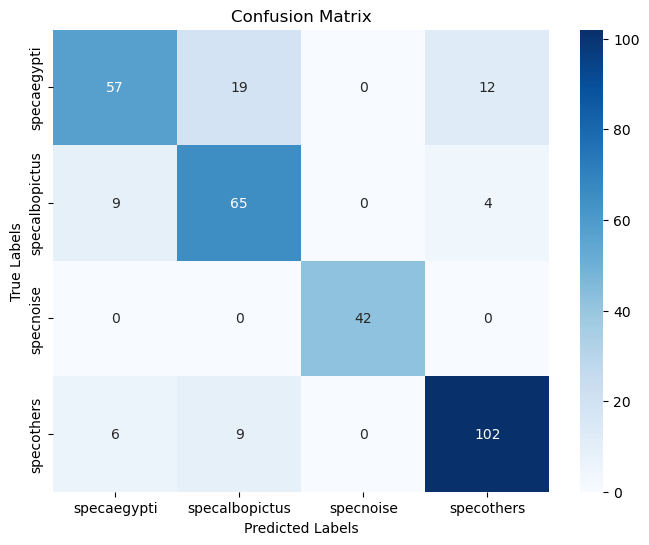

Classification Report:
                precision    recall  f1-score   support

   specaegypti       0.79      0.65      0.71        88
specalbopictus       0.70      0.83      0.76        78
     specnoise       1.00      1.00      1.00        42
    specothers       0.86      0.87      0.87       117

      accuracy                           0.82       325
     macro avg       0.84      0.84      0.84       325
  weighted avg       0.82      0.82      0.82       325



In [12]:
# 10 Model evaluation(PERFORMANCE using testing data(20%)
#Get the true labels and predictions
y_true = []
y_pred = []

# Loop through the validation dataset
for images, labels in val_ds:
    predictions = vit_classifier.predict(images)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

# Create the confusion matrix
cm = confusion_matrix(y_true, y_pred)
labels_names = val_ds.class_names

# Display the confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_names, yticklabels=labels_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Print classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=labels_names))


In [13]:
import numpy as np

# Compute metrics for each class
num_classes = len(labels_names)
metrics = {}

for i in range(num_classes):
    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP
    FP = np.sum(cm[:, i]) - TP
    TN = np.sum(cm) - (TP + FN + FP)

    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    accuracy = (TP + TN) / (TP + TN + FP + FN)

    metrics[labels_names[i]] = {
        "Sensitivity": round(sensitivity, 2),
        "Specificity": round(specificity, 2),
        "Accuracy": round(accuracy, 2),
    }

# Display the metrics
for class_name, values in metrics.items():
    print(f"Class {class_name}:")
    print(f"  Sensitivity: {values['Sensitivity']}")
    print(f"  Specificity: {values['Specificity']}")
    print(f"  Accuracy: {values['Accuracy']}\n")


Class specaegypti:
  Sensitivity: 0.65
  Specificity: 0.94
  Accuracy: 0.86

Class specalbopictus:
  Sensitivity: 0.83
  Specificity: 0.89
  Accuracy: 0.87

Class specnoise:
  Sensitivity: 1.0
  Specificity: 1.0
  Accuracy: 1.0

Class specothers:
  Sensitivity: 0.87
  Specificity: 0.92
  Accuracy: 0.9



# stop

Found 1628 files belonging to 4 classes.
Using 1303 files for training.
Found 1628 files belonging to 4 classes.
Using 325 files for validation.
Found 1628 files belonging to 4 classes.


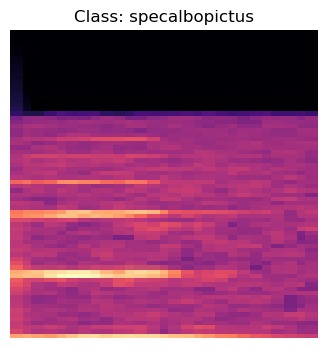

Image size: 72 X 72
Patch size: 6 X 6
Patches per image: 144
Elements per patch: 108


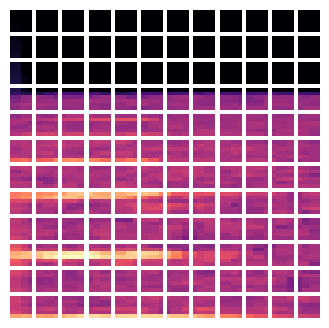

Epoch 1/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 53s 394ms/step - accuracy: 0.3597 - loss: 6.1586 - top-5-accuracy: 1.0000 - val_accuracy: 0.6000 - val_loss: 0.8906 - val_top-5-accuracy: 1.0000
Epoch 2/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 13s 314ms/step - accuracy: 0.5113 - loss: 1.6487 - top-5-accuracy: 1.0000 - val_accuracy: 0.6800 - val_loss: 0.6812 - val_top-5-accuracy: 1.0000
Epoch 3/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 13s 314ms/step - accuracy: 0.6104 - loss: 0.9306 - top-5-accuracy: 1.0000 - val_accuracy: 0.7108 - val_loss: 0.6594 - val_top-5-accuracy: 1.0000
Epoch 4/30
41/41 ━━━━━━━━━━━━━━━━━━━━ 13s 319ms/step - accuracy: 0.6408 - loss: 0.8077 - top-5-accuracy: 1.0000 - val_accuracy: 0.7569 - val_loss: 0.6216 - val_top-5-accuracy: 1.0000
Epoch 5/30
13/41 ━━━━━━━━━━━━━━━━━━━━ 7s 266ms/step - accuracy: 0.6284 - loss: 0.8378 - top-5-accuracy: 1.0000

KeyboardInterrupt: 

In [14]:
#coding JADI
import matplotlib.pyplot as plt
import keras
from keras import layers
from keras import ops
from keras.utils import image_dataset_from_directory
import numpy as np
import tensorflow as tf

# ----------------------------------------------------------------------
# 1. Prepare data
# ----------------------------------------------------------------------
# Load the datasets
data_dir = r"D:\faiza\data\spectogram4class"  # or wherever the data is
image_size = 224  # Consistent image size, from your provided image
batch_size = 32

train_ds = image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="categorical",
    image_size=(image_size, image_size),
    batch_size=batch_size,
    validation_split=0.2,
    subset="training",
    seed=42,
)
val_ds = image_dataset_from_directory(
    data_dir,
    labels="inferred",
    label_mode="categorical",
    image_size=(image_size, image_size),
    batch_size=batch_size,
    validation_split=0.2,
    subset="validation",
    seed=42,
)
temp_ds = image_dataset_from_directory(  # added for visualization
    data_dir,
    labels="inferred",
    label_mode="categorical",
    image_size=(image_size, image_size),
    batch_size=1,
    shuffle=True,
)

# ----------------------------------------------------------------------
# 2. Configure the hyperparameters
# ----------------------------------------------------------------------
patch_size = 16  # From your provided image
projection_dim = 64
num_heads = 4
transformer_units = [projection_dim * 2, projection_dim]
transformer_layers = 8
mlp_head_units = [2048, 1024]
num_classes = 4
num_epochs = 30
learning_rate = 0.001
weight_decay = 0.0001
input_shape = (image_size, image_size, 3)

# ----------------------------------------------------------------------
# 3. Use data augmentation
# ----------------------------------------------------------------------
data_augmentation = keras.Sequential(
    [
        layers.Normalization(),
        layers.Resizing(image_size, image_size),
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(factor=0.02),
        layers.RandomZoom(height_factor=0.2, width_factor=0.2),
    ],
    name="data_augmentation",
)

# Compute the mean and the variance of the training data for normalization.
#  Use .map to extract the images from the dataset
data_augmentation.layers[0].adapt(train_ds.map(lambda x, y: x))

# ----------------------------------------------------------------------
# 4. Implement MLP
# ----------------------------------------------------------------------
def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=keras.activations.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

# ----------------------------------------------------------------------
# 5. Implement patch creation as a layer
# ----------------------------------------------------------------------
class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        input_shape = ops.shape(images)
        batch_size = input_shape[0]
        height = input_shape[1]
        width = input_shape[2]
        channels = input_shape[3]
        num_patches_h = height // self.patch_size
        num_patches_w = width // self.patch_size
        patches = keras.ops.image.extract_patches(
            images,
            size=(self.patch_size, self.patch_size),
            strides=(self.patch_size, self.patch_size),
            padding="VALID",
        )
        patches = ops.reshape(
            patches,
            (
                batch_size,
                num_patches_h * num_patches_w,
                self.patch_size * self.patch_size * channels,
            ),
        )
        return patches

    def get_config(self):
        config = super().get_config()
        config.update({"patch_size": self.patch_size})
        return config

# ----------------------------------------------------------------------
# 6. Get this output: Image size, Patch size, Patches per image, Elements per patch
# ----------------------------------------------------------------------
# Take one image
for image_batch, label_batch in temp_ds.take(1):
    image = image_batch[0]

    # Display the original image
    plt.figure(figsize=(4, 4))
    plt.imshow(ops.convert_to_numpy(image).astype("uint8"))
    plt.title(f"Class: {temp_ds.class_names[ops.convert_to_numpy(label_batch).argmax()]}")
    plt.axis("off")
    plt.show()

    resized_image = ops.image.resize(
        ops.expand_dims(image, axis=0), size=(image_size, image_size)
    )
    patches = Patches(patch_size)(resized_image)

    print(f"Image size: {image_size} X {image_size}")
    print(f"Patch size: {patch_size} X {patch_size}")
    print(f"Patches per image: {patches.shape[1]}")
    print(f"Elements per patch: {patches.shape[-1]}")

    n = int(np.sqrt(patches.shape[1]))
    plt.figure(figsize=(4, 4))
    for i, patch in enumerate(patches[0]):
        ax = plt.subplot(n, n, i + 1)
        patch_img = ops.reshape(patch, (patch_size, patch_size, ops.shape(image)[-1]))
        plt.imshow(ops.convert_to_numpy(patch_img).astype("uint8"))
        plt.axis("off")
    plt.show()

# ----------------------------------------------------------------------
# 7. Implement the patch encoding layer
# ----------------------------------------------------------------------
class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(
            input_dim=num_patches, output_dim=projection_dim
        )

    def call(self, patch):
        positions = ops.expand_dims(
            ops.arange(start=0, stop=self.num_patches, step=1), axis=0
        )
        projected_patches = self.projection(patch)
        encoded = projected_patches + self.position_embedding(positions)
        return encoded

    def get_config(self):
        config = super().get_config()
        config.update({"num_patches": self.num_patches})
        return config

# ----------------------------------------------------------------------
# 8. Build the ViT model
# ----------------------------------------------------------------------
def create_vit_classifier():
    inputs = layers.Input(shape=input_shape)
    augmented_inputs = data_augmentation(inputs)  # Apply data augmentation
    patches = Patches(patch_size)(augmented_inputs)
    num_patches = (image_size // patch_size) ** 2
    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)

    for _ in range(transformer_layers):
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim, dropout=0.1
        )(x1, x1)
        x2 = layers.Add()([attention_output, encoded_patches])
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        x3 = mlp(x3, hidden_units=transformer_units, dropout_rate=0.1)
        encoded_patches = layers.Add()([x3, x2])

    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.Flatten()(representation)
    representation = layers.Dropout(0.5)(representation)
    features = mlp(representation, hidden_units=mlp_head_units, dropout_rate=0.5)
    logits = layers.Dense(num_classes, activation="softmax")(features)
    model = keras.Model(inputs=inputs, outputs=logits)
    return model

# ----------------------------------------------------------------------
# 9. Compile, train, and evaluate the model
# ----------------------------------------------------------------------
def run_experiment(model):
    optimizer = keras.optimizers.AdamW(
        learning_rate=learning_rate, weight_decay=weight_decay
    )
    model.compile(
        optimizer=optimizer,
        loss=keras.losses.CategoricalCrossentropy(from_logits=False),
        metrics=[
            keras.metrics.CategoricalAccuracy(name="accuracy"),
            keras.metrics.TopKCategoricalAccuracy(5, name="top-5-accuracy"),
        ],
    )

    checkpoint_filepath = "/tmp/checkpoint.weights.h5"
    checkpoint_callback = keras.callbacks.ModelCheckpoint(
        checkpoint_filepath,
        monitor="val_accuracy",
        save_best_only=True,
        save_weights_only=True,
    )

    history = model.fit(
        train_ds,
        epochs=num_epochs,
        validation_data=val_ds,
        callbacks=[checkpoint_callback],
    )

    model.load_weights(checkpoint_filepath)
    _, accuracy, top_5_accuracy = model.evaluate(val_ds)
    print(f"Validation accuracy: {round(accuracy * 100, 2)}%")
    print(f"Validation top 5 accuracy: {round(top_5_accuracy * 100, 2)}%")

    return history

def plot_history(item):
    plt.plot(history.history[item], label=item)
    plt.plot(history.history["val_" + item], label="val_" + item)
    plt.xlabel("Epochs")
    plt.ylabel(item)
    plt.title("Train and Validation {} Over Epochs".format(item), fontsize=14)
    plt.legend()
    plt.grid()
    plt.show()

# Instantiate and run
vit_classifier = create_vit_classifier()
history = run_experiment(vit_classifier)

# Plotting
plot_history("accuracy")
plot_history("top-5-accuracy")
plot_history("loss")
